In [1]:
!pip install torch
!pip install transforms


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset

transform = transforms.Compose([transforms.ToTensor()])

#  |          otherwise from ``t10k-images-idx3-ubyte``.
full_train_dataset = datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

subset_indices = range(1000)
mnist_subset = Subset(full_train_dataset, subset_indices)

print(f"Subset size: {len(mnist_subset)}")
print(type(mnist_subset[0]))
print(len(mnist_subset[0]))

image, label = mnist_subset[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")

Subset size: 1000
<class 'tuple'>
2
Image shape: torch.Size([1, 28, 28])
Label: 5


In [28]:

print(type(image)) # <class 'torch.Tensor'> -> Complex math grid
print(type(label)) # <class 'int'>          -> Simple number

<class 'torch.Tensor'>
<class 'int'>


In [ ]:
from torchvision import datasets
print(help(datasets.MNIST))

Help on class MNIST in module torchvision.datasets.mnist:

class MNIST(torchvision.datasets.vision.VisionDataset)
 |  MNIST(root: Union[str, pathlib.Path], train: bool = True, transform: Optional[Callable] = None, target_transform: Optional[Callable] = None, download: bool = False) -> None
 |  
 |  `MNIST <http://yann.lecun.com/exdb/mnist/>`_ Dataset.
 |  
 |  Args:
 |      root (str or ``pathlib.Path``): Root directory of dataset where ``MNIST/raw/train-images-idx3-ubyte``
 |          and  ``MNIST/raw/t10k-images-idx3-ubyte`` exist.
 |      train (bool, optional): If True, creates dataset from ``train-images-idx3-ubyte``,
 |          otherwise from ``t10k-images-idx3-ubyte``.
 |      transform (callable, optional): A function/transform that  takes in a PIL image
 |          and returns a transformed version. E.g, ``transforms.RandomCrop``
 |      target_transform (callable, optional): A function/transform that takes in the
 |          target and transforms it.
 |      download (bool, 

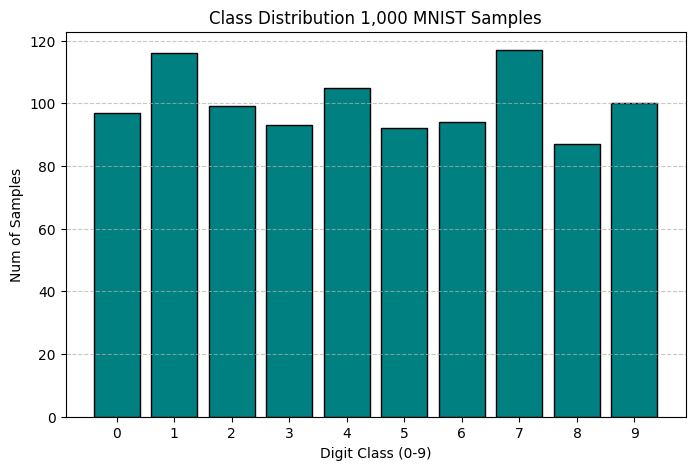

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Subset
# torch.histogram(torch.tensor(mnist_subset), range = None, weight= None, density= False, out= None)

label = []
for item in mnist_subset:
    label.append(item[1])

# integer to float!!!!
label_tensor = torch.tensor(label, dtype= torch.float32)

plt.figure(figsize=(8, 5))
plt.hist(label, bins=np.arange(11) - 0.5, rwidth=0.8, color='teal', edgecolor='black')
plt.title('Class Distribution 1,000 MNIST Samples')
plt.xlabel('Digit Class (0-9)')
plt.ylabel('Num of Samples')
plt.xticks(range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# we need some libraries for this demo
!pip install einops numpy pillow -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
# 3. Use the einops python package to ‘batch’ the subset of MNIST images. Each
# batch should contain 25 different sample

from einops import rearrange

all_images = torch.stack([image for image, label in mnist_subset])
all_images_2d = all_images.squeeze() 
print(f"Starting shape: {all_images_2d.shape}") 

batched_images = rearrange(
    all_images_2d, 
    '(N_batches b_size) h w -> N_batches b_size 1 h w', 
    b_size=25
)

print(f"Final batched shape: {batched_images.shape}") 


Starting shape: torch.Size([1000, 28, 28])
Final batched shape: torch.Size([40, 25, 1, 28, 28])


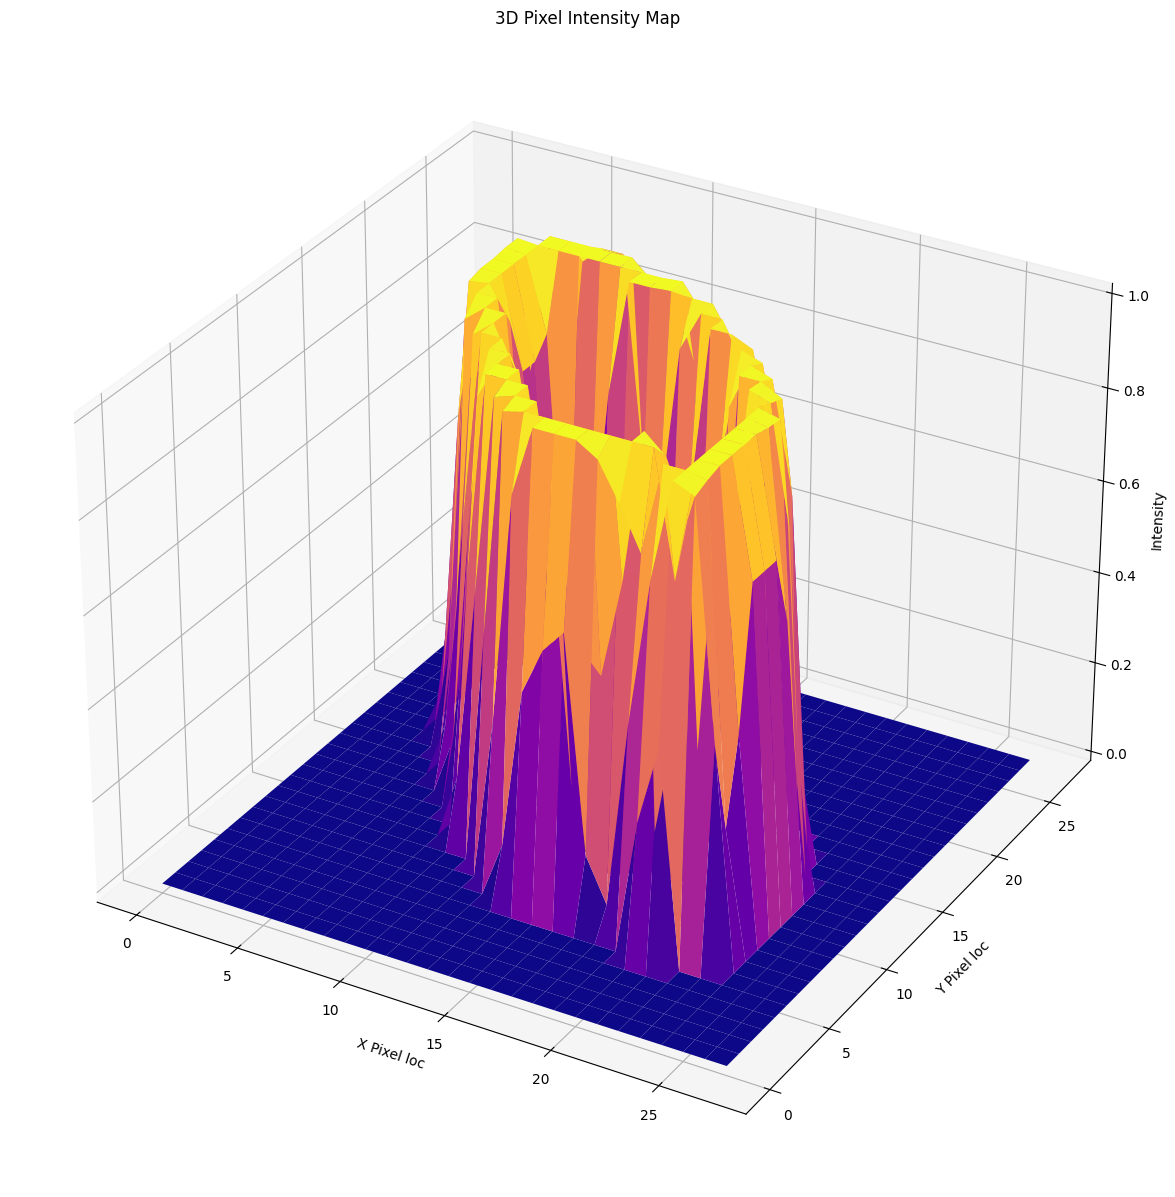

In [61]:
# 4. Randomly select an MNIST image sample and, using matplotlib, plot it in three
# dimensions. The x and y-axis’ should be the respective pixel locations, and the
# z-axis should be the pixel intensit

import random

random_idx = random.randint(0, len(mnist_subset) - 1)
image_tensor, label = mnist_subset[random_idx]

# Squeeze removes the channel dimension. [1, 28, 28] - > [28, 28]
Z = image_tensor.squeeze().numpy()

x = np.arange(0, 28)
y = np.arange(0, 28)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d') 
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none')

ax.set_title(f"3D Pixel Intensity Map")
ax.set_xlabel("X Pixel loc")
ax.set_ylabel("Y Pixel loc")
ax.set_zlabel("Intensity")

plt.show()

In [62]:
# 2.2 Time Series

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    'energydata_complete.csv', 
    parse_dates=['date'], 
    index_col='date'
)

print(df.index)

DatetimeIndex(['2016-01-11 17:00:00', '2016-01-11 17:10:00',
               '2016-01-11 17:20:00', '2016-01-11 17:30:00',
               '2016-01-11 17:40:00', '2016-01-11 17:50:00',
               '2016-01-11 18:00:00', '2016-01-11 18:10:00',
               '2016-01-11 18:20:00', '2016-01-11 18:30:00',
               ...
               '2016-05-27 16:30:00', '2016-05-27 16:40:00',
               '2016-05-27 16:50:00', '2016-05-27 17:00:00',
               '2016-05-27 17:10:00', '2016-05-27 17:20:00',
               '2016-05-27 17:30:00', '2016-05-27 17:40:00',
               '2016-05-27 17:50:00', '2016-05-27 18:00:00'],
              dtype='datetime64[ns]', name='date', length=19735, freq=None)


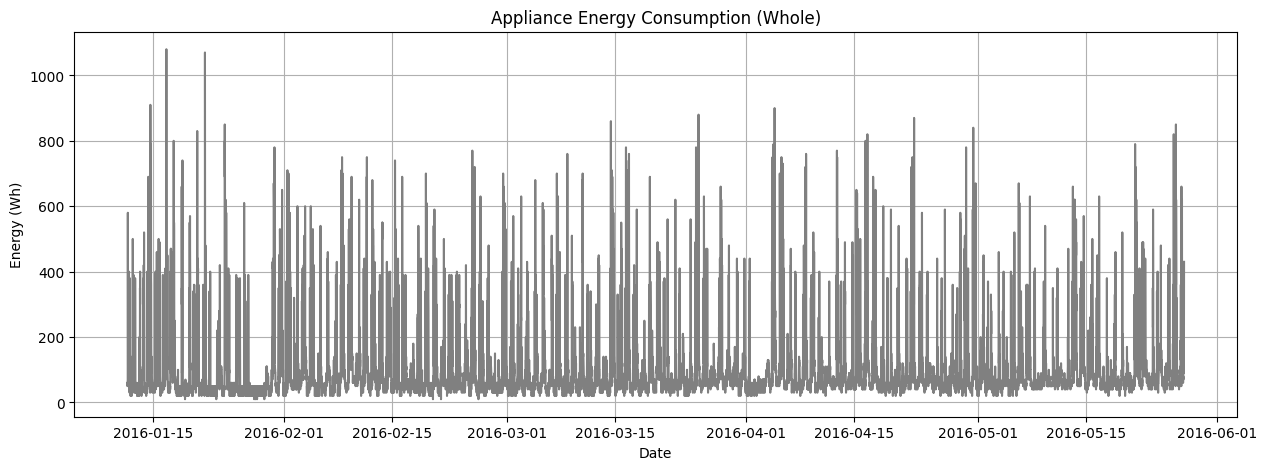

In [71]:
plt.figure(figsize=(15, 5)) 
plt.plot(df.index, df['Appliances'], color='gray')

plt.title('Appliance Energy Consumption (Whole)')
plt.ylabel('Energy (Wh)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

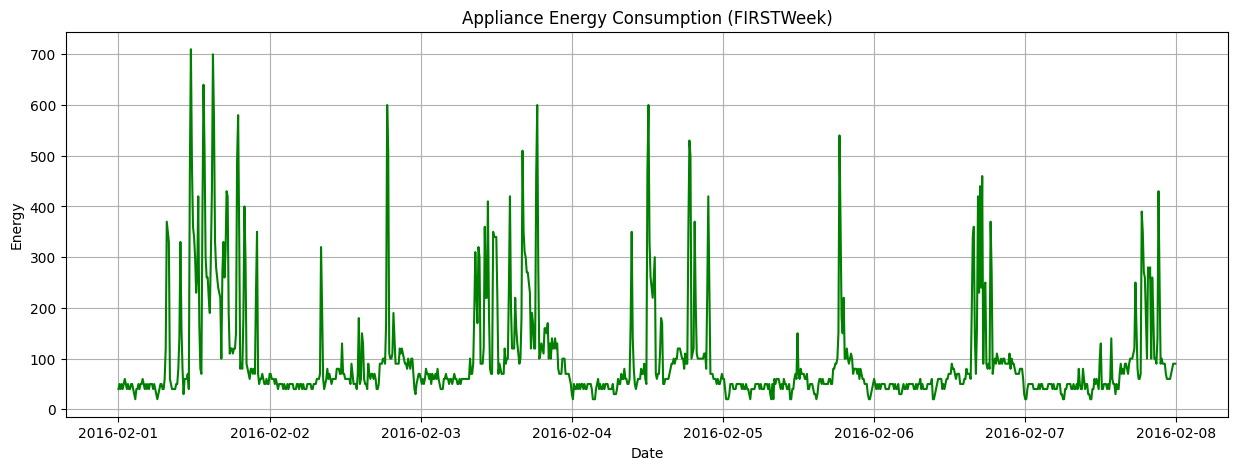

In [76]:
one_week= df.loc['2016-02-01':"2016-02-07"]
plt.figure(figsize=(15, 5)) 

plt.plot(one_week.index, one_week['Appliances'], color='green')

plt.title('Appliance Energy Consumption (FIRSTWeek)')
plt.ylabel('Energy')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [125]:
one_week_df = df.loc['2016-02-01':'2016-02-07'].copy()

hourly_data = one_week_df['Appliances'].resample('H').sum().reset_index()

hourly_data['Hour'] = hourly_data['date'].dt.hour

# Extract the day name 
hourly_data['Day'] = hourly_data['date'].dt.day_name()

# Reshape the data into a grid
heatmap_data = hourly_data.pivot_table(
    values='Appliances', 
    index='Day', 
    columns='Hour'
)


C:\Users\park2\AppData\Local\Temp\ipykernel_20976\2398534581.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = one_week_df['Appliances'].resample('H').sum().reset_index()


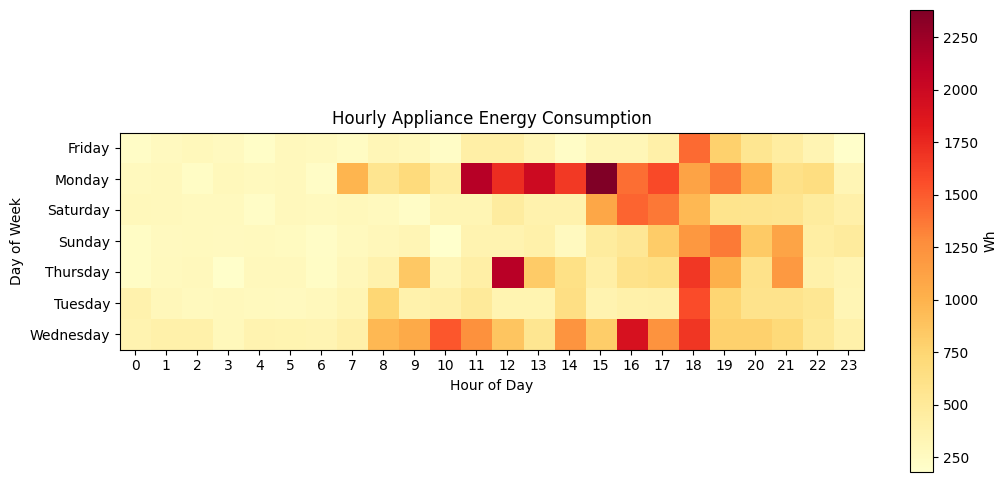

In [126]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))
matrix = ax.imshow(heatmap_data, cmap='YlOrRd')
fig.colorbar(matrix, label='Wh')

ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

ax.set_title("Hourly Appliance Energy Consumption")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.show()

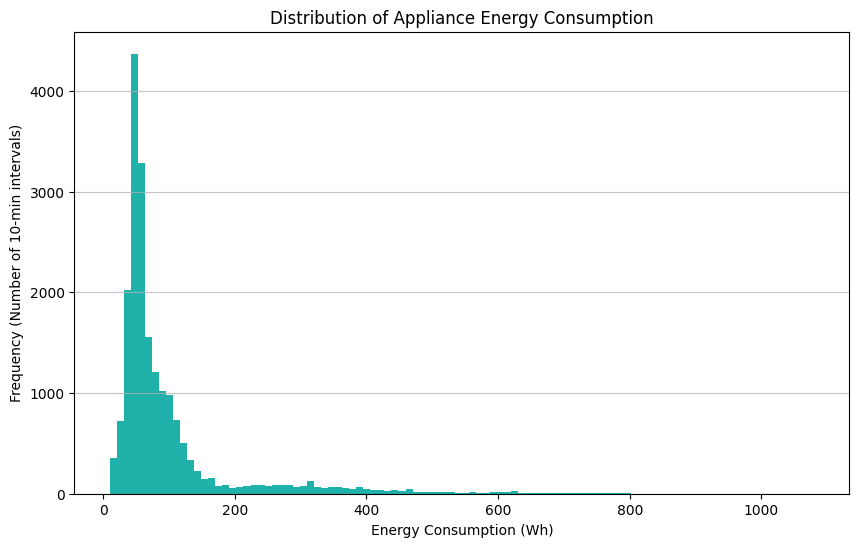

In [124]:
# 3. Plot the histogram of energy consumption of appliances.

plt.figure(figsize=(10, 6))

# Plot the histogram with 50 'bins' (buckets) to get a granular view
plt.hist(df['Appliances'], bins=100, color='lightseagreen')

plt.title('Distribution of Appliance Energy Consumption')
plt.xlabel('Energy Consumption (Wh)')
plt.ylabel('Frequency (Number of 10-min intervals)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [110]:
mean_val = df['Appliances'].mean()
var_val = df['Appliances'].var()
std_val = df['Appliances'].std() 

print("======= Energy Statistics ========")
print(f"Mean (Average):       {mean_val:.3f} Wh")
print(f"Variance:             {var_val:.3f}")
print(f"Standard Deviation:   {std_val:.3f} Wh")

print(f"Gaussian Distribution: N({mean_val:.3f}, {var_val:.3f})")

======= Energy Statistics ========
Mean (Average):       97.695 Wh
Variance:             10511.353
Standard Deviation:   102.525 Wh
Gaussian Distribution: N(97.695, 10511.353)


In [128]:
hours_to_sec = df.index.hour * 3600
minutes_to_sec = df.index.minute * 60

df['NSM'] = hours_to_sec + minutes_to_sec 

print(df[['Appliances', 'NSM']])

                     Appliances    NSM
date                                  
2016-01-11 17:00:00          60  61200
2016-01-11 17:10:00          60  61800
2016-01-11 17:20:00          50  62400
2016-01-11 17:30:00          50  63000
2016-01-11 17:40:00          60  63600
...                         ...    ...
2016-05-27 17:20:00         100  62400
2016-05-27 17:30:00          90  63000
2016-05-27 17:40:00         270  63600
2016-05-27 17:50:00         420  64200
2016-05-27 18:00:00         430  64800

[19735 rows x 2 columns]


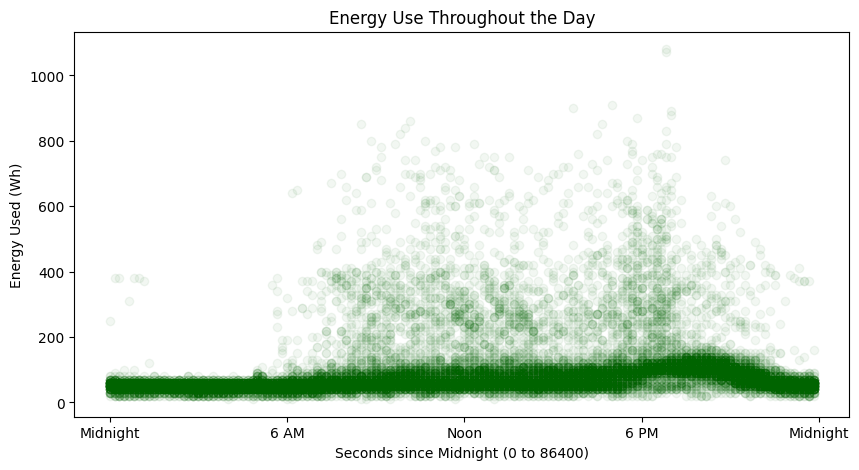

In [134]:
# 4. Construct a feature variable NSM (no. of seconds from midnight) and plot energy
# consumption vs. NSM.

plt.figure(figsize=(10, 5))

plt.scatter(df['NSM'], df['Appliances'], alpha=0.05, color='darkgreen')

# Add basic labels
plt.title('Energy Use Throughout the Day')
plt.xlabel('Seconds since Midnight (0 to 86400)')
plt.ylabel('Energy Used (Wh)')
plt.xticks([0, 21600, 43200, 64800, 86400], 
           ['Midnight', '6 AM', 'Noon', '6 PM', 'Midnight'])
plt.show()

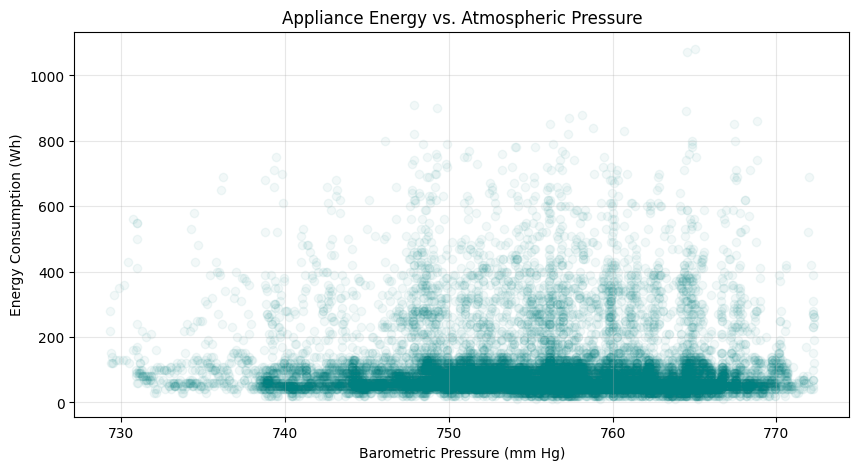

In [ ]:
# 5. Plot appliances energy consumption vs. Press mm Hg.


plt.figure(figsize=(10, 5))

# Pressure on the X-axis and Appliances on the Y-axis
plt.scatter(df['Press_mm_hg'], df['Appliances'], alpha=0.05, color='teal')

plt.title('Appliance Energy vs. Atmospheric Pressure')
plt.xlabel('Barometric Pressure (mm Hg)')
plt.ylabel('Energy Consumption (Wh)')

plt.grid(True, alpha=0.3)
plt.show()

# 6. It is observed that the major contributing factors for the energy consumption
# among all other features is NSM and Press mm Hg. Comment on it

Well, NSM (no of sec from midnight) is showing human activities indoors and therefore, it reveals directly on their electronics usage.

This tells that humans are mainly staying on active from 8 AM to 8 PM and the rest of the times are sort of by default rate, such utilities like heating, fridge,
generic house keeping electricity, whereas human factors come into play with addition of TV, cookers, induction ovens, PCs and whatnot.

Second, Pressure is a bit tricky. Low pressure usually means cloudy and rainy weather. Hgih pressure does mean sunny but highly heated environment where you don't want to go outside (not really but more of my assupmption) but rather stay under AC. In certain cases, people stay indoors, and that reveals why people may have a higher chance. But most of them are showing the bottom on the 740 to 770. That means as 1atm is at 760mm, The atmosphere always stays with in 740 to 770 and most people live under uniform distirubution over pressure.

In [150]:
columns = [
    'Frequency(Hzz)', 'Angle_of_Attack(Degr)', 'Chord_Length(m)', 'Velocity(m/s)', 'Displacement_Thickness(m)', 'Sound_Pressure_dB'
]
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat"

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df = pd.read_csv(url, sep='\s+', names=columns)

print(df)

      Frequency(Hzz)  Angle_of_Attack(Degr)  Chord_Length(m)  Velocity(m/s)  Displacement_Thickness(m)  Sound_Pressure_dB
0                800                    0.0           0.3048           71.3                   0.002663            126.201
1               1000                    0.0           0.3048           71.3                   0.002663            125.201
2               1250                    0.0           0.3048           71.3                   0.002663            125.951
3               1600                    0.0           0.3048           71.3                   0.002663            127.591
4               2000                    0.0           0.3048           71.3                   0.002663            127.461
...              ...                    ...              ...            ...                        ...                ...
1498            2500                   15.6           0.1016           39.6                   0.052849            110.264
1499            3150    

In [149]:
# 2. Compute the Descriptive Statistics
summary = pd.DataFrame({
    'Mean': df.mean(),
    'Variance': df.var(),
    'Median': df.median(),
    'Kurtosis': df.kurtosis(),
    'Skewness': df.skew(),
    'Range': df.max() - df.min()
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("=== Descriptive Statistics for Airfoil Dataset ===")
print(summary)

=== Descriptive Statistics for Airfoil Dataset ===
                               Mean      Variance       Median  Kurtosis  Skewness         Range
Frequency               2886.380572  9.938717e+06  1600.000000  5.708685  2.137084  19800.000000
Angle_of_Attack            6.782302  3.502424e+01     5.400000 -0.412951  0.689164     22.200000
Chord_Length               0.136548  8.749868e-03     0.101600 -1.037964  0.457457      0.279400
Velocity                  50.860745  2.425116e+02    39.600000 -1.563951  0.235852     39.600000
Displacement_Thickness     0.011140  1.729287e-04     0.004957  2.218903  1.702165      0.058011
Sound_Pressure_dB        124.835943  4.759146e+01   125.721000 -0.314187 -0.418952     37.607000
